<a href="https://colab.research.google.com/github/x-senpai-x/Options-Pricing/blob/main/Merton_Jump_Diffusion_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Merton Jump Diffusion Model

The Merton Jump diffusion model is a result of Robert C. Merton's  1979 paper Option Pricing When Underlying Stock Returns Are Discountious. The main idea regarding this paper was to extend the Black-Scholes model to incorporate more realistic assumptions and that deal with the fact that empirical studies of market returns, do not follow a constant variance log-normal distribution.



## Snippet to Simulate Jump Diffusion

Text(0.5, 1.0, 'Jump Diffusion Process')

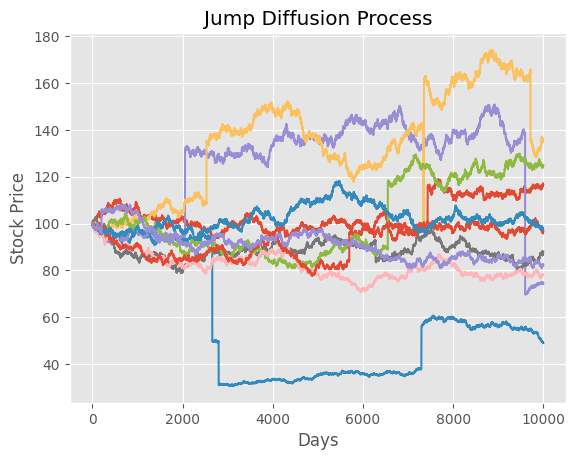

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np

def merton_jump_paths(S, T, r, sigma,  lam, m, v, steps, Npaths):
    size=(steps,Npaths)
    dt = T/steps
    poi_rv = np.multiply(np.random.poisson( lam*dt, size=size),
                         np.random.normal(m,v, size=size)).cumsum(axis=0)
    geo = np.cumsum(((r -  sigma**2/2 -lam*(m  + v**2*0.5))*dt +\
                              sigma*np.sqrt(dt) * \
                              np.random.normal(size=size)), axis=0)

    return np.exp(geo+poi_rv)*S


S = 100 # current stock price
T = 1 # time to maturity
r = 0.02 # risk free rate
m = 0 # meean of jump size
v = 0.3 # standard deviation of jump
lam =1 # intensity of jump i.e. number of jumps per annum
steps =10000 # time steps
Npaths = 10 # number of paths to simulate
sigma = 0.2 # annaul standard deviation , for weiner process

j = merton_jump_paths(S, T, r, sigma, lam, m, v, steps, Npaths)

plt.plot(j)
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Jump Diffusion Process')

 Price for options that follow a jump diffusion process must always be higher than the standard Black-Scholes formula. Since we are adding randomness (which benefits the option holder), options writers should demand a larger premium for assets that follow a jump diffusion process.

Merton derived the following solution to price options that follow a jump diffusion process. The summation below takes the Black-Scholes price conditional on knowing exactly how many jumps will occur and weights these values by their corresponding probability under the Poisson distribution.

![image.png](attachment:00c793c9-eac6-4d27-b331-ace2d9f19ba0.png)
![image.png](attachment:793393cf-94f5-4e04-bac6-18838facb5ab.png)
![image.png](attachment:0212b80f-8a6b-4489-8b51-4f79f6fb9c98.png)

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize_scalar
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
N = norm.cdf

def BS_CALL(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * N(d1) - K * np.exp(-r*T)* N(d2)

def BS_PUT(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma* np.sqrt(T)
    return K*np.exp(-r*T)*N(-d2) - S*N(-d1)


def merton_jump_call(S, K, T, r, sigma, m , v, lam):
    p = 0
    for k in range(40):
        r_k = r - lam*(m-1) + (k*np.log(m) ) / T
        sigma_k = np.sqrt( sigma**2 + (k* v** 2) / T)
        k_fact = np.math.factorial(k)
        p += (np.exp(-m*lam*T) * (m*lam*T)**k / (k_fact))  * BS_CALL(S, K, T, r_k, sigma_k)

    return p

def merton_jump_put(S, K, T, r, sigma, m , v, lam):
    p = 0 # price of option
    for k in range(40):
        r_k = r - lam*(m-1) + (k*np.log(m) ) / T
        sigma_k = np.sqrt( sigma**2 + (k* v** 2) / T)
        k_fact = np.math.factorial(k) #
        p += (np.exp(-m*lam*T) * (m*lam*T)**k / (k_fact)) \
                    * BS_PUT(S, K, T, r_k, sigma_k)
    return p

def implied_vol(opt_value, S, K, T, r, type_='call'):

    def call_obj(sigma):
        return abs(BS_CALL(S, K, T, r, sigma) - opt_value)

    def put_obj(sigma):
        return abs(BS_PUT(S, K, T, r, sigma) - opt_value)

    if type_ == 'call':
        res = minimize_scalar(call_obj, bounds=(0.01,6), method='bounded')
        return res.x
    elif type_ == 'put':
        res = minimize_scalar(put_obj, bounds=(0.01,6),
                              method='bounded')
        return res.x
    else:
        raise ValueError("type_ must be 'put' or 'call'")

In [ ]:
from datetime import datetime as dt , timedelta as td
S = 23275 # current stock price
T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365# time to maturity
r = 0.06857 # risk free rate
m = 0 # meean of jump size
v = 0.3 # standard deviation of jump
lam = 1 # intensity of jump i.e. number of jumps per annum
steps =255 # time steps
Npaths =200000 # number of paths to simulate
sigma = 0.1395 # annaul standard deviation , for weiner process
K =23700
np.random.seed(3)
j = merton_jump_paths(S, T, r, sigma, lam, m, v, steps, Npaths) #generate jump diffusion paths
cf_price =  merton_jump_call(S, K, T, r, sigma, np.exp(m+v**2*0.5) , v, lam)
print('Merton Price =', cf_price)
print('Black Scholes Price =', BS_CALL(S,K,T,r, sigma))



Merton Price = 373.0060879863783
Black Scholes Price = 199.0429088150313


C:\Users\khush\AppData\Local\Temp\ipykernel_15224\3589937230.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  k_fact = np.math.factorial(k)


## Volatility Smile from Merton's Model

C:\Users\khush\AppData\Local\Temp\ipykernel_15224\1603446150.py:25: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  k_fact = np.math.factorial(k)


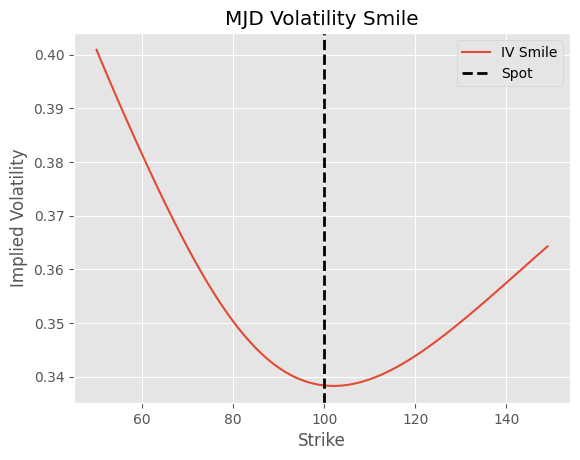

In [ ]:
S = 100
strikes = np.arange(50,150,1)
r = 0.02
m = 1 #when m =1 the mean is zero as it represents the average jump size as a multiple of the stock price.
v = 0.3
lam =1
sigma = 0.2
T= 1

mjd_prices = np.array([merton_jump_call(S, K_i, T, r, sigma, m, v, lam) for K_i in strikes])
merton_ivs = [implied_vol(c, S, k, T, r) for c,k in zip(mjd_prices, strikes)]

plt.plot(strikes, merton_ivs, label='IV Smile')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.axvline(S, color='black', linestyle='dashed', linewidth=2,label="Spot")
plt.title('MJD Volatility Smile')
plt.legend()

## Model Calibration to Market Prices

 least squares is used to fit the closed form solution discussed above to market data. Vmkt is the price of the option observed in the market.

![image.png](attachment:93b901cc-581e-461a-bb0a-f9ae94f8693b.png)
m represents the average jump size as a multiple of the stock price.

In [ ]:
import pandas as pd
import time
from scipy.optimize import minimize

df = pd.read_csv('https://raw.githubusercontent.com/codearmo/data/master/calls_calib_example.csv')

print(df.head(10))

   Strike  Moneyness     Bid  Midpoint     Ask        F     T
0   900.0       0.76  2856.1   2867.55  2879.0  3803.79  0.74
1  1000.0       0.74  2757.0   2768.45  2779.9  3803.79  0.74
2  1100.0       0.71  2658.0   2669.45  2680.9  3803.79  0.74
3  1200.0       0.68  2559.1   2570.55  2582.0  3803.79  0.74
4  1300.0       0.66  2460.3   2471.75  2483.2  3803.79  0.74
5  1400.0       0.63  2361.6   2373.05  2384.5  3803.79  0.74
6  1500.0       0.61  2263.0   2274.45  2285.9  3803.79  0.74
7  1550.0       0.59  2213.8   2225.25  2236.7  3803.79  0.74
8  1600.0       0.58  2164.7   2176.15  2187.6  3803.79  0.74
9  1650.0       0.57  2115.6   2126.20  2136.8  3803.79  0.74


The given data is of S&P500 index in 2021
- Bid Price – The highest price a buyer is willing to pay for a stock.
- Ask Price – The lowest price a seller is willing to accept for a stock.
- Midpoint Price – The average of the bid and ask prices
- F : Current stock price
- T : Time to expiry

We are using an initial guess for σ = 0.15, m = 1, v = 0.10 and λ=1


In [ ]:
def optimal_params(x, mkt_prices, strikes):
    candidate_prices = merton_jump_call(S, strikes, T, r,
                                        sigma=x[0], m= x[1] ,
                                        v=x[2],lam= x[3])
    return np.linalg.norm(mkt_prices - candidate_prices, 2)


T = df['T'].values[0]
S = df.F.values[0]
r = 0
x0 = [0.15, 1, 0.1, 1] # initial guess for algorithm
bounds = ((0.01, np.inf) , (0.01, 2), (1e-5, np.inf) , (0, 5)) #bounds as described above
strikes = df.Strike.values
prices = df.Midpoint.values

res = minimize(optimal_params, method='SLSQP',  x0=x0, args=(prices, strikes),
                  bounds = bounds, tol=1e-20,
                  options={"maxiter":1000})
sigt = res.x[0]
mt = res.x[1]
vt = res.x[2]
lamt = res.x[3]

print('Calibrated Volatlity = ', sigt)
print('Calibrated Jump Mean = ', mt)
print('Calibrated Jump Std = ', vt)
print('Calibrated intensity = ', lamt)

C:\Users\khush\AppData\Local\Temp\ipykernel_15224\1603446150.py:25: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  k_fact = np.math.factorial(k)


Calibrated Volatlity =  0.06489493056802963
Calibrated Jump Mean =  0.878904820627237
Calibrated Jump Std =  0.15420407626704757
Calibrated intensity =  0.972293080781065


C:\Users\khush\AppData\Local\Temp\ipykernel_15224\1603446150.py:25: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  k_fact = np.math.factorial(k)


Text(0.5, 1.0, 'Merton Model Optimal Params')

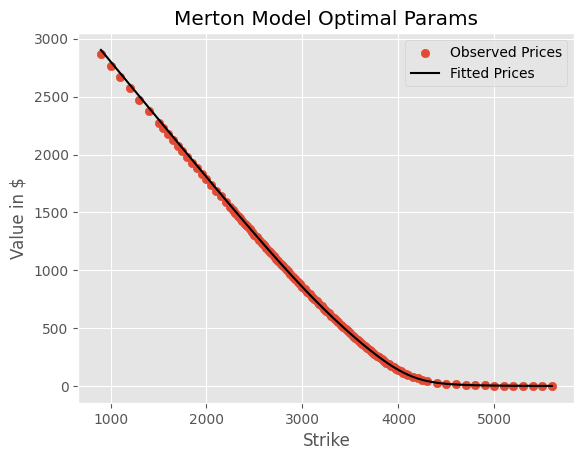

In [ ]:
df['least_sq_V'] = merton_jump_call(S, df.Strike, df['T'], 0 ,sigt, mt, vt, lamt)

plt.scatter(df.Strike, df.Midpoint,label= 'Observed Prices')
plt.plot(df.Strike, df.least_sq_V, color='black',label= 'Fitted Prices')
plt.legend()
plt.xlabel('Strike')
plt.ylabel('Value in $')
plt.title('Merton Model Optimal Params')